# Boosted Decision Tree Skeleton


In [1]:
import awkward as ak
import uproot
import polars as pl

from fastfeedback import DataManager, Method

method = 0b00
direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
energy_reco = Method.Truth if method & 1 << 1 else Method.Reco

print(f"""
Direction reconstruction: {direc_reco.name}
Energy reconstruction:    {energy_reco.name}
""")

data_manager = DataManager("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")
data_manager.set_data_selection(pl.lit(True))
data_manager.set_direc_reco(direc_reco)
data_manager.set_energy_reco(energy_reco)

df = data_manager.prepare_data()
df = df["recoE", "direc_reco"]

caf_tree = uproot.open("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")["cafTree"]
Enu_e_had = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_had"
Enu_e_calo = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_calo"
Enu_mu_had = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_had"
Enu_mu_range = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_range"
nuPDG = "rec/mc/mc.nu/mc.nu.pdg"
true_inelasticity = "rec/mc/mc.nu/mc.nu.inelasticity"

df2 = pl.from_pandas(
    ak.to_dataframe(
        caf_tree.arrays(
            [Enu_e_had, Enu_e_calo, Enu_mu_had, Enu_mu_range, nuPDG, true_inelasticity]
        ),
        how="outer",
    ),
)
df2.columns = [
    "Enu_e_had",
    "Enu_e_calo",
    "Enu_mu_had",
    "Enu_mu_range",
    "nuPDG",
    "true_inelasticity",
]

event_daughters_tree = uproot.open("example-cafs-root/event_daughters_info.root")[
    "event_daughters_tree"
]
event_daughters_df: pl.DataFrame = pl.from_pandas(
    event_daughters_tree.arrays(library="pd")
)
event_daughters_true_df = event_daughters_df[
    "n_true_nu",
    "n_primary_daughters",
    "n_primary_electrons",
    "n_primary_muons",
    "n_primary_protons",
    "n_primary_pions",
    "n_primary_photons",
    "n_primary_pi0s",
    "n_primary_tracks",
    "n_primary_showers",
    "reco_ok",
]
event_daughters_reco_df = event_daughters_df[
    "reco_ok",
    "n_reco_pfps",
    "n_reco_tracks",
    "single_hits_energy",
    "n_reco_muons_pions",
    "n_reco_protons",
    "n_reco_showers",
]

electron_mask = pl.col("nuPDG").abs() == 12
muon_mask = pl.col("nuPDG").abs() == 14

electron_inelasticity = 1 - (pl.col("Enu_e_had") / pl.col("Enu_e_calo"))
muon_inelasticity = 1 - (pl.col("Enu_mu_had") / pl.col("Enu_mu_range"))

data: pl.DataFrame = (
    pl.concat([df, df2, event_daughters_reco_df], how="horizontal")
    .filter(pl.col("reco_ok") == True)
    .with_columns(
        pl.when(electron_mask)
        .then(electron_inelasticity)
        .when(muon_mask)
        .then(muon_inelasticity)
        .otherwise(None)
        .alias("reco_inelasticity")
    )
    .drop("true_inelasticity")
)

data


Direction reconstruction: Reco
Energy reconstruction:    Reco

Loading data...


/software/xn22103/miniconda/envs/dune-atmo-osc/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:454: RuntimeWarning: invalid value encountered in cast
  return self._module.concatenate(arrays, axis=axis, casting="same_kind")


Finished loading data


recoE,direc_reco,Enu_e_had,Enu_e_calo,Enu_mu_had,Enu_mu_range,nuPDG,reco_ok,n_reco_pfps,n_reco_tracks,single_hits_energy,n_reco_muons_pions,n_reco_protons,n_reco_showers,reco_inelasticity
f64,f64,f32,f32,f32,f32,i32,bool,i32,i32,f32,i32,i32,i32,f32
28.432413,-0.291152,12.376396,28.432413,28.015844,28.529816,-12,true,10,5,11.48799,4,1,4,0.564708
0.208079,0.092648,0.09995,0.208079,0.09995,0.322256,-12,true,2,1,0.11094,1,0,0,0.519653
1.20171,0.167917,0.306345,1.156426,0.306345,1.20171,-14,true,4,3,0.06457,2,1,0,0.745076
0.5937,0.577708,0.088844,0.502835,0.088844,0.5937,14,true,3,2,0.00242,1,1,0,0.850355
0.299485,-0.333278,0.003319,0.299485,0.003319,0.299201,16,true,2,1,0.003319,1,0,0,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2.243878,0.899609,-8.1044e-17,0.156685,0.0,0.256748,14,true,2,1,0.0,1,0,0,1.0
0.260973,-0.396677,0.002552,0.169946,0.002552,0.260973,14,true,2,1,0.005397,1,0,0,0.990219
0.271612,0.695405,0.014027,0.12414,0.014027,0.207403,14,true,3,1,0.012165,1,0,1,0.932367


In [ ]:
import matplotlib.pyplot as plt

nu_mask = pl.col("nuPDG") > 0
nubar_mask = pl.col("nuPDG") < 0

for col in data.columns:
    if col in ["nuPDG", "reco_ok", "n_true_nu"]:
        continue

    _, bins, _ = plt.hist(
        data.filter(nu_mask)[col],
        label="neutrino",
        histtype="step",
        bins=20,
    )
    plt.hist(
        data.filter(nubar_mask)[col],
        label="antineutrino",
        histtype="step",
        bins=bins,
    )
    plt.legend()
    plt.yscale("log")
    plt.xlabel(col)
    plt.ylabel("Events")
    plt.show()

In [2]:
from sklearn.model_selection import train_test_split
import numpy as np

# get your input data into an array which is N_events x N_variables
X_data = data.drop("nuPDG")

# create an array of truth labels (one per event) - 0 for neutrino, 1 for anti-neutrino
y_data = (data["nuPDG"] < 0).to_numpy().astype(int)
y_data_uniques = np.unique(y_data)
print(y_data_uniques)

# split the data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, random_state=0)
X_data

[0 1]


recoE,direc_reco,Enu_e_had,Enu_e_calo,Enu_mu_had,Enu_mu_range,reco_ok,n_reco_pfps,n_reco_tracks,single_hits_energy,n_reco_muons_pions,n_reco_protons,n_reco_showers,reco_inelasticity
f64,f64,f32,f32,f32,f32,bool,i32,i32,f32,i32,i32,i32,f32
28.432413,-0.291152,12.376396,28.432413,28.015844,28.529816,true,10,5,11.48799,4,1,4,0.564708
0.208079,0.092648,0.09995,0.208079,0.09995,0.322256,true,2,1,0.11094,1,0,0,0.519653
1.20171,0.167917,0.306345,1.156426,0.306345,1.20171,true,4,3,0.06457,2,1,0,0.745076
0.5937,0.577708,0.088844,0.502835,0.088844,0.5937,true,3,2,0.00242,1,1,0,0.850355
0.299485,-0.333278,0.003319,0.299485,0.003319,0.299201,true,2,1,0.003319,1,0,0,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…
2.243878,0.899609,-8.1044e-17,0.156685,0.0,0.256748,true,2,1,0.0,1,0,0,1.0
0.260973,-0.396677,0.002552,0.169946,0.002552,0.260973,true,2,1,0.005397,1,0,0,0.990219
0.271612,0.695405,0.014027,0.12414,0.014027,0.207403,true,3,1,0.012165,1,0,1,0.932367


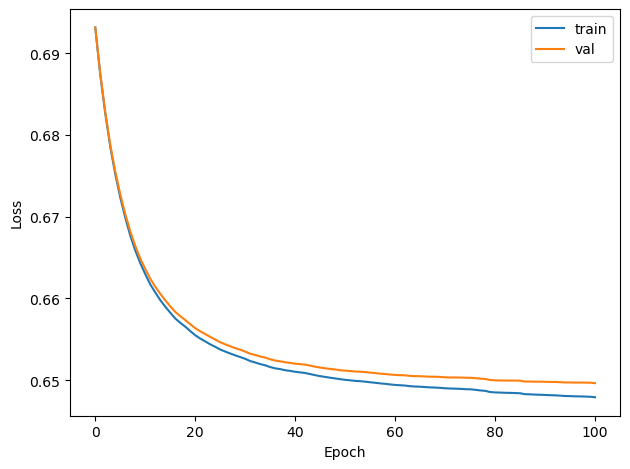

In [3]:
from sklearn.ensemble import HistGradientBoostingClassifier
import matplotlib.pyplot as plt

clf = HistGradientBoostingClassifier(random_state=0, class_weight="balanced").fit(
    X_train, y_train
)

train_loss = -clf.train_score_
val_loss = -clf.validation_score_

plt.plot(train_loss, label="train")
plt.plot(val_loss, label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("loss-graph.svg")

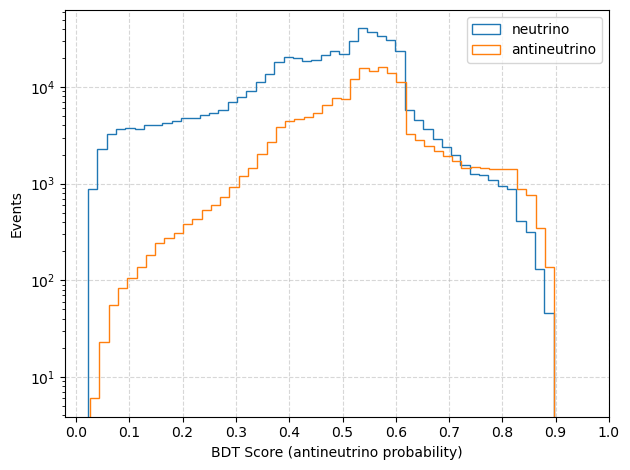

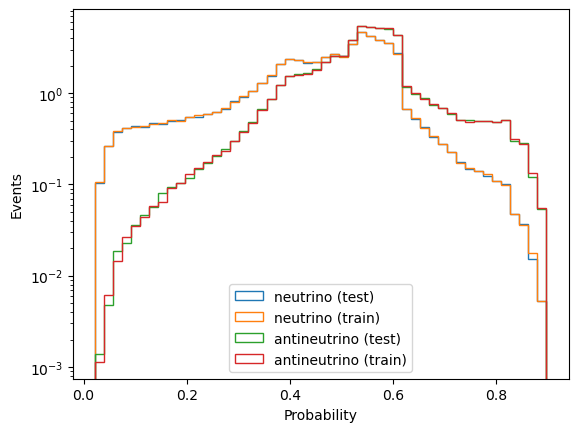

In [15]:
nu_index = 0
nubar_index = 1

scores_test = clf.predict_proba(X_test)[:, 1]
scores_train = clf.predict_proba(X_train)[:, 1]

prob_test_nu = scores_test[y_test == nu_index]
prob_test_nubar = scores_test[y_test == nubar_index]
prob_train_nu = scores_train[y_train == nu_index]
prob_train_nubar = scores_train[y_train == nubar_index]

_, bins, _ = plt.hist(prob_test_nu, label="neutrino", histtype="step", bins=50)
plt.hist(prob_test_nubar, label="antineutrino", histtype="step", bins=50)

plt.xlabel("BDT Score (antineutrino probability)")
plt.xticks(np.arange(0, 1.1, 0.1))
plt.ylabel("Events")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.grid(linestyle="--", alpha=0.5)
plt.savefig("bdt_score_histograph.svg")
plt.show()

_, bins, _ = plt.hist(
    prob_test_nu, label="neutrino (test)", histtype="step", bins=50, density=True
)
plt.hist(
    prob_train_nu, label="neutrino (train)", histtype="step", bins=bins, density=True
)
plt.hist(
    prob_test_nubar,
    label="antineutrino (test)",
    histtype="step",
    bins=bins,
    density=True,
)
plt.hist(
    prob_train_nubar,
    label="antineutrino (train)",
    histtype="step",
    bins=bins,
    density=True,
)
plt.legend()
plt.yscale("log")
plt.xlabel("Probability")
plt.ylabel("Events")
plt.show()

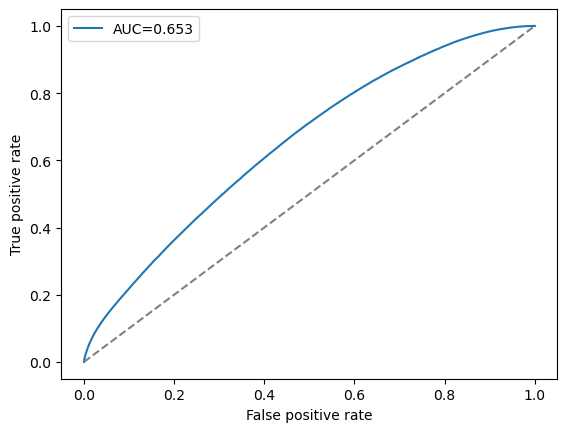

In [19]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, scores_test)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.savefig("roc-auc.svg")

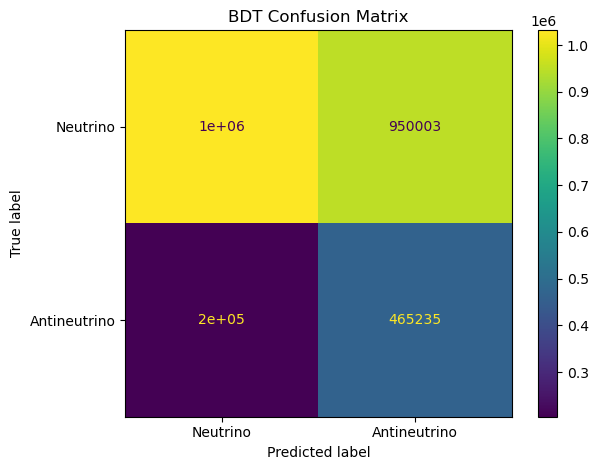

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_data.to_pandas())
cm = confusion_matrix(y_data, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=["Neutrino", "Antineutrino"])
disp.plot()
plt.title("BDT Confusion Matrix")
plt.tight_layout()
plt.savefig("bdt-confusion-matrix.svg")

In [ ]:
from sklearn.inspection import permutation_importance

r = permutation_importance(clf, X_data.to_pandas(), y_data, random_state=0)
for name, val in sorted(zip(X_data.columns, r["importances_mean"]), key=lambda x: x[1]):
    print(name, val)

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import awkward as ak
import uproot
import polars as pl
from sklearn.ensemble import HistGradientBoostingClassifier
from scipy.integrate import trapezoid

from fastfeedback import DataManager, Method

auc_table = {
    "Direction": [],
    "Energy": [],
    "Inelasticity": [],
    "Events": [],
    "AUC": [],
}


# method:
# bbbb
#    ^ direction reconstruction
#   ^ energy reconstruction
#  ^ inelasticity
# ^ events
def auc_plots(method: int):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    inelasticity = method & 1 << 2 != 0
    events = method & 1 << 3 != 0

    print(f"""
Direction reconstruction: {direc_reco.name}
Energy reconstruction:    {energy_reco.name}
Inelasticity:             {"Truth" if inelasticity else "Reco"}
Events:                   {"Truth" if events else "Reco"}
""")

    data_manager = DataManager("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")
    data_manager.set_data_selection(pl.lit(True))
    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)

    df = data_manager.prepare_data()
    df = df["recoE", "direc_reco"]

    caf_tree = uproot.open("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")[
        "cafTree"
    ]
    Enu_e_had = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_had"
    Enu_e_calo = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_calo"
    Enu_mu_had = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_had"
    Enu_mu_range = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_range"
    nuPDG = "rec/mc/mc.nu/mc.nu.pdg"
    true_inelasticity = "rec/mc/mc.nu/mc.nu.inelasticity"

    df2 = pl.from_pandas(
        ak.to_dataframe(
            caf_tree.arrays(
                [
                    Enu_e_had,
                    Enu_e_calo,
                    Enu_mu_had,
                    Enu_mu_range,
                    nuPDG,
                    true_inelasticity,
                ]
            ),
            how="outer",
        ),
    )
    df2.columns = [
        "Enu_e_had",
        "Enu_e_calo",
        "Enu_mu_had",
        "Enu_mu_range",
        "nuPDG",
        "true_inelasticity",
    ]

    event_daughters_tree = uproot.open("example-cafs-root/event_daughters_info.root")[
        "event_daughters_tree"
    ]
    event_daughters_df: pl.DataFrame = pl.from_pandas(
        event_daughters_tree.arrays(library="pd")
    )
    event_daughters_true_df = event_daughters_df[
        "n_true_nu",
        "n_primary_daughters",
        "n_primary_electrons",
        "n_primary_muons",
        "n_primary_protons",
        "n_primary_pions",
        "n_primary_photons",
        "n_primary_pi0s",
        "n_primary_tracks",
        "n_primary_showers",
        "reco_ok",
    ]
    event_daughters_reco_df = event_daughters_df[
        "reco_ok",
        "n_reco_pfps",
        "n_reco_tracks",
        "single_hits_energy",
        "n_reco_muons_pions",
        "n_reco_protons",
        "n_reco_showers",
    ]

    electron_mask = pl.col("nuPDG").abs() == 12
    muon_mask = pl.col("nuPDG").abs() == 14

    electron_inelasticity = 1 - (pl.col("Enu_e_had") / pl.col("Enu_e_calo"))
    muon_inelasticity = 1 - (pl.col("Enu_mu_had") / pl.col("Enu_mu_range"))

    if events:
        events_df = event_daughters_true_df
    else:
        events_df = event_daughters_reco_df

    data: pl.DataFrame = (
        pl.concat([df, df2, events_df], how="horizontal")
        .filter(pl.col("reco_ok") == True)
        .filter(pl.col("direc_reco") != 0)
        .with_columns(
            pl.when(electron_mask)
            .then(electron_inelasticity)
            .when(muon_mask)
            .then(muon_inelasticity)
            .otherwise(None)
            .alias("reco_inelasticity")
        )
        .drop_nulls()
    )

    if not inelasticity:
        data.drop_in_place("true_inelasticity")

    # get your input data into an array which is N_events x N_variables
    X_data = data.drop("nuPDG")

    # create an array of truth labels (one per event) - 0 for neutrino, 1 for anti-neutrino
    y_data = (data["nuPDG"] < 0).to_numpy().astype(int)
    y_data_uniques = np.unique(y_data)
    print(y_data_uniques)

    # split the data into train and test datasets
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, random_state=0)

    clf = HistGradientBoostingClassifier(random_state=0, class_weight="balanced").fit(
        X_train, y_train
    )

    scores_test = clf.decision_function(X_test)

    nu_index = 0
    nubar_index = 1

    prob_test_nu = 1 / (1 + np.exp(scores_test[y_test == nu_index]))
    prob_test_nubar = 1 / (1 + np.exp(scores_test[y_test == nubar_index]))

    score_thresh = np.linspace(0, 1, 200)

    tpr = [(prob_test_nu > score).sum() / len(prob_test_nu) for score in score_thresh]
    fpr = [
        (prob_test_nubar > score).sum() / len(prob_test_nubar) for score in score_thresh
    ]

    auc = trapezoid(x=fpr[::-1], y=tpr[::-1])

    auc_table["Direction"].append(direc_reco.name)
    auc_table["Energy"].append(energy_reco.name)
    auc_table["Inelasticity"].append("Truth" if inelasticity else "Reco")
    auc_table["Events"].append("Truth" if events else "Reco")
    auc_table["AUC"].append(auc)


for i in [
    0b0000,
    0b0001,
    0b0010,
    0b0100,
    0b1000,
    0b1111,
    0b1110,
    0b1101,
    0b1011,
    0b0111,
]:
    auc_plots(i)

auc_table = pl.DataFrame(auc_table)
auc_table